In [1]:
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Input
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import imquality.brisque as brisque
from tensorflow.keras.layers import MaxPooling2D, Flatten, Conv2D, Dense, BatchNormalization, GlobalAveragePooling2D, Dropout, AveragePooling2D
from tensorflow.keras.applications.densenet import DenseNet169
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.resnet50 import ResNet50
from sklearn.metrics import accuracy_score
from tensorflow.keras.applications.efficientnet import EfficientNetB7
from tensorflow.keras.applications.vgg16 import VGG16
import pandas as pd
import pickle
import os
import cv2

In [2]:
images_normal = []
images_ACGAN = []
images_WGAN = []
for folder in os.listdir('NIH Dataset/Images_NORMAL/train'):
    for idx, image in enumerate(os.listdir('NIH Dataset/Images_NORMAL/train/' + folder)):
        if idx == 3:
            break
        img = cv2.imread('NIH Dataset/Images_NORMAL/train/' + folder + '/' + image)
        images_normal.append(img)
    for idx, image in enumerate(os.listdir('Generated Images/ACGAN/' + folder)):
        if idx == 3:
            break
        img = cv2.imread('Generated Images/ACGAN/' + folder + '/' + image)
        images_ACGAN.append(img)
    for idx, image in enumerate(os.listdir('Generated Images/WGAN/' + folder)):
        if idx == 3:
            break
        img = cv2.imread('Generated Images/WGAN/' + folder + '/' + image)
        images_WGAN.append(img)

In [7]:
brisques_ACGAN = []
brisques_WGAN = []
for image in images_ACGAN:
    brisques_ACGAN.append(brisque.score(image))
for image in images_WGAN:
    brisques_WGAN.append(brisque.score(image))
    
# The lower the better
print("Brisque Score of the ACGAN images is", np.average(brisques_ACGAN))
print("Brisque Score of the WGAN images is", np.average(brisques_WGAN))

Brisque Score of the ACGAN images is 19.083812020975284
Brisque Score of the WGAN images is 14.467248739259546


## Remember the PSNR and SSIM scores might not be absolutely correct because for each generated image, we don't have a paired ground truth to compare it with. Instead we are comparing it with any normal image of the same class

In [9]:
PSNRs_ACGAN = []
PSNRs_WGAN = []
for idx in range(len(images_normal)):
    PSNRs_ACGAN.append(psnr(images_normal[idx], images_ACGAN[idx]))
    PSNRs_WGAN.append(psnr(images_normal[idx], images_WGAN[idx]))

# The higher the better. Less than 20 is considered bad
print("PSNR of the ACGAN images is", np.average(PSNRs_ACGAN))
print("PSNR of the WGAN images is", np.average(PSNRs_WGAN))

PSNR of the ACGAN images is 11.8927687181317
PSNR of the WGAN images is 11.854138433287474


In [11]:
SSIMs_ACGAN = []
SSIMs_WGAN = []
for idx in range(len(images_normal)):
    SSIMs_ACGAN.append(ssim(images_normal[idx], images_ACGAN[idx], channel_axis = 2))
    SSIMs_WGAN.append(ssim(images_normal[idx], images_WGAN[idx], channel_axis = 2))

# The low scores indicate high degradation in generated images
print("SSIM of the ACGAN images is", np.average(SSIMs_ACGAN))
print("SSIM of the WGAN images is", np.average(SSIMs_WGAN))

SSIM of the ACGAN images is 0.3107012800799617
SSIM of the WGAN images is 0.32051633822710296


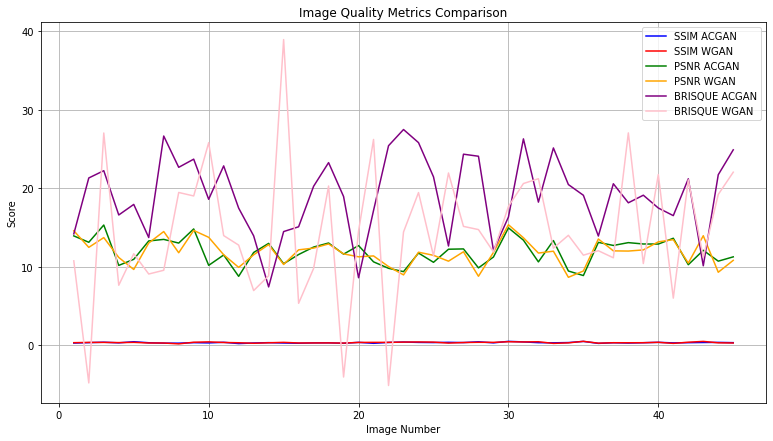

In [16]:
num_samples = len(SSIMs_ACGAN)
x_values = np.linspace(1, num_samples, num_samples)

plt.figure(figsize = (13, 7))

plt.plot(x_values, SSIMs_ACGAN, label = 'SSIM ACGAN', color = 'blue')
plt.plot(x_values, SSIMs_WGAN, label = 'SSIM WGAN', color = 'red')

plt.plot(x_values, PSNRs_ACGAN, label = 'PSNR ACGAN', color = 'green')
plt.plot(x_values, PSNRs_WGAN, label = 'PSNR WGAN', color = 'orange')

plt.plot(x_values, brisques_ACGAN, label = 'BRISQUE ACGAN', color = 'purple')
plt.plot(x_values, brisques_WGAN, label = 'BRISQUE WGAN', color = 'pink')

plt.xlabel('Image Number')
plt.ylabel('Score')
plt.title('Image Quality Metrics Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
def limit_data(data_dir, n = 1000):
    a = []
    for i in os.listdir(data_dir):
        for k, j in enumerate(os.listdir(data_dir + '/' + i)):
            if k > n:
                continue
            a.append((f'{data_dir}/{i}/{j}', i))
    return pd.DataFrame(a, columns = ['filename', 'class'])

In [48]:
df = limit_data('NIH Dataset/Images_NOISED/train', n = 5000)

In [50]:
image_gen = ImageDataGenerator(
    rescale = 1. / 255,
)
train_set = image_gen.flow_from_dataframe(
    df,
    target_size = (128, 128),
    batch_size = 16,
    class_mode = 'categorical',
)
valid_set = image_gen.flow_from_directory(
    'NIH Dataset/Images_NOISED/valid',
    target_size = (128, 128),
    batch_size = 16,
    class_mode = 'categorical'
)

Found 29770 validated image filenames belonging to 15 classes.
Found 1500 images belonging to 15 classes.


In [51]:
in_shape = (128, 128, 3)
in_layer = Input(shape = in_shape)

densenet = DenseNet169(weights = 'imagenet', input_shape = in_shape, include_top = False)
mobilenet = MobileNetV2(weights = 'imagenet', input_shape = in_shape, include_top = False)
for layer in mobilenet.layers:
    layer.trainable = False
for layer in densenet.layers:
    layer.trainable = False
model_mobilenet = mobilenet(in_layer)
model_mobilenet = GlobalAveragePooling2D()(model_mobilenet)
output_mobilenet = Flatten()(model_mobilenet)
model_densenet = densenet(in_layer)
model_densenet = GlobalAveragePooling2D()(model_densenet)
output_densenet = Flatten()(model_densenet)
concatenated = tf.keras.layers.Concatenate()([output_mobilenet, output_densenet])
X = BatchNormalization()(concatenated)
X = Dense(64, activation = 'relu')(X)
X = Dense(15, activation = 'softmax')(X)

model = tf.keras.models.Model(inputs = in_layer, outputs = X)

In [52]:
rlr = ReduceLROnPlateau(monitor = "val_accuracy", factor = 0.01, patience = 6, verbose = 0, mode = "max", min_delta = 0.01)

In [53]:
class AUCMetric(tf.keras.metrics.Metric):
    def __init__(self, name = 'auc', **kwargs):
        super(AUCMetric, self).__init__(name = name, **kwargs)
        self.auc = tf.keras.metrics.AUC(num_thresholds = 200, multi_label = True, num_labels = 15)

    def update_state(self, y_true, y_pred, sample_weight = None):
        self.auc.update_state(y_true, y_pred, sample_weight)

    def result(self):
        return self.auc.result()

    def reset_states(self):
        self.auc.reset_states()

# def focal_loss(alpha = 0.5, beta = 2.0):
#     epsilon = 1.e-7
#     def loss_fn(y_true, y_pred):
#         y_true = tf.cast(y_true, tf.float32)
#         y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
#         alpha_t = y_true * alpha + (tf.ones_like(y_true) - y_true) * (1 - alpha)
#         y_t = tf.multiply(y_true, y_pred) + tf.multiply(1 - y_true, 1 - y_pred)
#         ce = -tf.math.log(y_t)
#         weight = tf.pow(tf.subtract(1., y_t), beta)
#         fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
#         loss = tf.reduce_mean(fl)
#         return loss
#     return loss_fn

In [54]:
optim = Adam(learning_rate = 0.001)
model.compile(loss = 'categorical_crossentropy', optimizer = optim, metrics = ['accuracy', AUCMetric()])

In [55]:
history = model.fit(train_set, steps_per_epoch = 29770 // 16, epochs = 5, batch_size = 16, validation_data = valid_set, callbacks = [rlr])

Epoch 1/5
1860/1860 [==============================] - ETA: 0s - loss: 2.1937 - accuracy: 0.2492 - auc: 0.7790

C:\Users\Muhammad Darab\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric AUCMetric implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


1860/1860 [==============================] - 821s 432ms/step - loss: 2.1937 - accuracy: 0.2492 - auc: 0.7790 - val_loss: 2.8425 - val_accuracy: 0.1367 - val_auc: 0.6490 - lr: 0.0010
Epoch 2/5
1860/1860 [==============================] - 208s 112ms/step - loss: 1.9586 - accuracy: 0.3275 - auc: 0.8306 - val_loss: 3.0336 - val_accuracy: 0.1387 - val_auc: 0.6454 - lr: 0.0010
Epoch 3/5
1860/1860 [==============================] - 204s 110ms/step - loss: 1.8527 - accuracy: 0.3663 - auc: 0.8511 - val_loss: 3.0585 - val_accuracy: 0.1527 - val_auc: 0.6489 - lr: 0.0010
Epoch 4/5
1860/1860 [==============================] - 207s 111ms/step - loss: 1.7555 - accuracy: 0.4042 - auc: 0.8672 - val_loss: 3.0449 - val_accuracy: 0.1547 - val_auc: 0.6572 - lr: 0.0010
Epoch 5/5
1860/1860 [==============================] - 214s 115ms/step - loss: 1.6811 - accuracy: 0.4283 - auc: 0.8790 - val_loss: 3.0672 - val_accuracy: 0.1513 - val_auc: 0.6602 - lr: 0.0010


In [56]:
model.save('Weights/Model_NOISED.h5')

In [57]:
class History_trained_model(object):
    def __init__(self, history, epoch, params):
        self.history = history
        self.epoch = epoch
        self.params = params

with open('Weights/Histories/History_NOISED', 'wb') as file:
    model_history = History_trained_model(history.history, history.epoch, history.params)
    pickle.dump(model_history, file, pickle.HIGHEST_PROTOCOL)

In [58]:
with open('Weights/Histories/History_NOISED', 'rb') as file:
    history = pickle.load(file)

print(history.history)

{'loss': [2.1937108039855957, 1.9586167335510254, 1.852735161781311, 1.755493402481079, 1.681056022644043], 'accuracy': [0.2492101937532425, 0.32745176553726196, 0.3662700951099396, 0.40418094396591187, 0.42831215262413025], 'auc': [0.7790475487709045, 0.830588698387146, 0.8510660529136658, 0.867215096950531, 0.878987729549408], 'val_loss': [2.842533588409424, 3.033621311187744, 3.0584940910339355, 3.0449154376983643, 3.0672097206115723], 'val_accuracy': [0.1366666704416275, 0.13866665959358215, 0.15266667306423187, 0.15466666221618652, 0.15133333206176758], 'val_auc': [0.6489897966384888, 0.6453709006309509, 0.6488662958145142, 0.657216489315033, 0.6601978540420532], 'lr': [0.001, 0.001, 0.001, 0.001, 0.001]}


In [60]:
with open('Weights/Histories/History_NORMAL', 'rb') as file:
    history_NORMAL = pickle.load(file)

with open('Weights/Histories/History_NOISED', 'rb') as file:
    history_NOISED = pickle.load(file)

with open('Weights/Histories/History_ACGAN', 'rb') as file:
    history_ACGAN = pickle.load(file)

with open('Weights/Histories/History_WCGAN', 'rb') as file:
    history_WCGAN = pickle.load(file)

In [63]:
history_NORMAL.history['val_auc']

[0.6347262263298035,
 0.6608571410179138,
 0.6530417203903198,
 0.6292678713798523,
 0.6259048581123352]

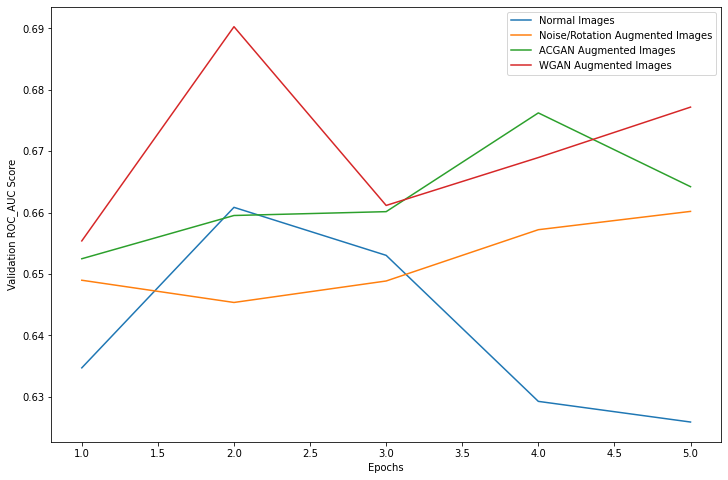

In [77]:
epochs = [1, 2, 3, 4, 5]
plt.figure(figsize = (12, 8))
plt.plot(epochs, history_NORMAL.history['val_auc'], label = 'Normal Images')
plt.plot(epochs, history_NOISED.history['val_auc'], label = 'Noise/Rotation Augmented Images')
plt.plot(epochs, history_ACGAN.history['val_auc'], label = 'ACGAN Augmented Images')
plt.plot(epochs, history_WCGAN.history['val_auc'], label = 'WGAN Augmented Images')
plt.xlabel('Epochs')
plt.ylabel('Validation ROC_AUC Score')
plt.legend()
plt.show()